<a href="https://colab.research.google.com/github/MatteoCorsi-git/Master-Data-Science-Statistical-Learning---UNIFI-IMT-Lucca---2024-25/blob/main/Deep_Learning_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MD2SL Deep Learning Assignment: Convolutional Neural Networks

In this laboratory session we will train some CNNs to recognize color images in the [CIFAR-10 Dataset](https://www.cs.toronto.edu/~kriz/cifar.html).

## IMPORTANT
+ Make sure to **interpret** your results and include detailed analysis using the rich markup features of Jupyter. Don't just submit code -- even if it works you **won't** receive full credit.
+ There is a plethora of information on building and training CNNs for image recognition (even for *exactly* this CIFAR-10 dataset). **Absolutely** make use of all available material, **but the solutions you submit must be your own**.

## Part 1: Initial Setup and Data Exploration

We begin with some standard imports, as usual.

In [ ]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

# Standard Pytorch imports (note the aliases).
import torch
import torch.nn as nn
import torch.nn.functional as F

### Exercise 1.1: Dataset and Dataloader Preparation

The `torchvision` library provides a class (with the same interface as MNIST) for the CIFAR-10 dataset. As with MNIST, it will automatically download and prepare the dataset for use. Use the CIFAR10 class to load the training, validation (use 2000 images), and test splits.

**Note**: Don't forget to *transform* the images in the datasets to convert them to tensors and standardize them!

**Hint**: Feel free to copy-and-paste liberally from the notebook I published for the capsule lecture. **BUT**, make sure you know what you are doing, and be aware that *some* of the code will have to be adapted for use with the CIFAR10 dataset.

In [ ]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import random_split

# Validation set size.
val_size = 2000

# 1. Define transformations for the images
# The mean and std values are the standard, pre-computed values for the CIFAR-10 dataset across RGB channels.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2470, 0.2435, 0.2616))
])

# 2. Download and load the full training dataset
full_train_dataset = CIFAR10(root='./data',
                             train=True,
                             download=True,
                             transform=transform)

# 3. Download and load the test dataset
test_dataset = CIFAR10(root='./data',
                       train=False,
                       download=True,
                       transform=transform)

# 4. Split the full training dataset into Training and Validation sets
# Calculate the remaining size for the training set
train_size = len(full_train_dataset) - val_size

# Set a seed for reproducibility
torch.manual_seed(42)

# Perform the random split
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Print the sizes
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

## Comment
In this section, we prepare the **CIFAR-10** dataset for our Convolutional Neural Networks.

**Transformations Applied:**
1. `transforms.ToTensor()`: This converts the PIL Images into PyTorch FloatTensors of shape `(C, H, W)` and scales the pixel values to the range `[0.0, 1.0]`.
2. `transforms.Normalize()`: We standardize the dataset using the pre-computed mean `(0.4914, 0.4822, 0.4465)` and standard deviation `(0.2470, 0.2435, 0.2616)` for the Red, Green, and Blue channels of the CIFAR-10 dataset respectively. Standardization (Z-score normalization) centers the data around zero, which helps the gradient descent algorithm converge faster and avoids issues like vanishing or exploding gradients.

**Dataset Splitting:**
The original dataset provides a Train split (50,000 images) and a Test split (10,000 images). To monitor our model for overfitting during training, we extract a **Validation Set** of 2,000 images from the original training set. We use `torch.utils.data.random_split` with a fixed random seed (`torch.manual_seed(42)`) to ensure that our splits are strictly reproducible across different runs. The final distribution is:
*   **Training Set:** 48,000 images
*   **Validation Set:** 2,000 images
*   **Test Set:** 10,000 images

### Exercise 1.2: Dataloaders
Set up dataloaders for **all** of the datasets -- even though the validation set is small! Test out the datasets defined above and the dataloaders to make sure you understand the dataset format. Visualize some of the images to get a feel for the type of images and classes in CIFAR-10.

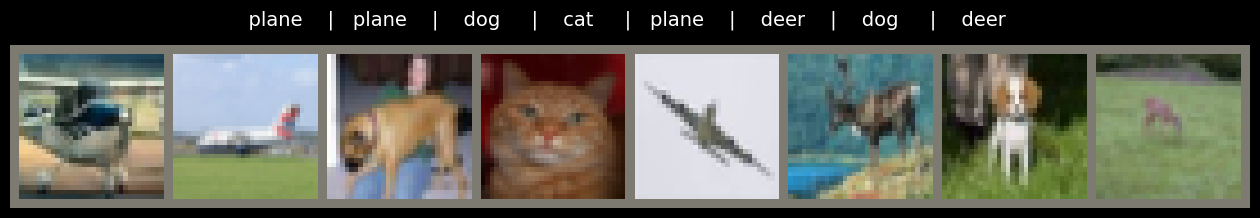

Batch images tensor shape: torch.Size([256, 3, 32, 32]) -> (batch_size, channels, height, width)
Batch labels tensor shape: torch.Size([256]) -> (batch_size)


In [15]:
from torch.utils.data import DataLoader
import torchvision

# Setup dataloaders for all three datasets. Use the largest batch size possible.
batch_size = 256

# 1. Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# CIFAR-10 class names for visualization
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# 2. Function to de-normalize and visualize an image
def imshow(img):

    # Create tensors for mean and std, reshaping them to (3, 1, 1) so they broadcast over (C, H, W)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

    # De-normalize
    img = img * std + mean

    # Convert from PyTorch Tensor to numpy array
    npimg = img.numpy()

    # Clip values to [0, 1] to avoid matplotlib warnings due to floating point precision
    npimg = np.clip(npimg, 0, 1)

    # PyTorch images are (Channels, Height, Width)
    # Matplotlib expects (Height, Width, Channels), so we transpose
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

# 3. Get a random batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# We don't want to show all 256 images, so let's just pick the first 8
num_images = 8
images_to_show = images[:num_images]
labels_to_show = labels[:num_images]

# 4. Plot the images
plt.figure(figsize=(16, 4))
# make_grid aligns the images in a neat grid automatically
imshow(torchvision.utils.make_grid(images_to_show))

# Print labels as the title of the plot
title_string = " | ".join(f"{classes[labels_to_show[j]]:^10s}" for j in range(num_images))
plt.title(title_string, fontsize=14, pad=15)
plt.axis('off') # Hide axes for cleaner visualization
plt.show()

# Print tensor shapes to demonstrate understanding of the data format
print(f"Batch images tensor shape: {images.shape} -> (batch_size, channels, height, width)")
print(f"Batch labels tensor shape: {labels.shape} -> (batch_size)")

### Comment

In this section, we instantiate PyTorch `DataLoader` objects for our datasets and visualize a subset of the data.

**DataLoader Configuration:**
*   **Batch Size:** We use a batch size of `256` as requested, which means our CNN will process 256 images simultaneously in each forward/backward pass.
*   **Shuffling:** We set `shuffle=True` exclusively for the `train_loader`. This breaks any sequential correlation in the training data, ensuring that the gradient descent steps are stochastic and preventing the model from learning spurious sequence-based patterns. The `val_loader` and `test_loader` are not shuffled (`shuffle=False`), as sequential order does not impact the calculation of evaluation metrics.

**Visualization and Data Format:**
To correctly visualize the images, we had to address two main technical differences between PyTorch tensors and Matplotlib requirements:
1.  **De-normalization:** In Exercise 1.1, we normalized the images to have a mean of 0 and a standard deviation of 1 using the formula $Z = \frac{X - \mu}{\sigma}$. Passing standard normal distributions directly to `plt.imshow` yields heavily distorted colors. We reversed this process using the algebraic inverse $X = Z \cdot \sigma + \mu$.
2.  **Dimensionality Permutation:** PyTorch handles image tensors in the `[Channels, Height, Width]` format. However, Matplotlib expects images in the `[Height, Width, Channels]` format. We used `np.transpose` to permute the axes accordingly.

As verified by our print statements, each batch outputting from the dataloader is a 4D tensor of shape `(256, 3, 32, 32)`, perfectly formatted to be fed into a Convolutional Neural Network layer. Looking at the visual output, we can observe that CIFAR-10 images are quite low-resolution ($32 \times 32$ pixels).

## Part 2: Establishing a stable baseline

In this part of the laboratory we will establish a simple baseline as a starting point.

### Exercise 2.1: An MLP Baseline

Define a simple Multilayer Perceptron to classify the CIFAR-10 images. Define it as a class inheriting from torch.nn.Module. Don't make it too complex or too deep. We're just looking for a starting point. A *baseline*.

In [ ]:
class MLPBaseline(nn.Module):
    def __init__(self):
        super(MLPBaseline, self).__init__()

        # 1. Flatten layer: converts the 3D image tensor (C, H, W) into a 1D vector
        self.flatten = nn.Flatten()

        # 2. Fully Connected (Linear) layers
        # Input features: 3 channels * 32 height * 32 width = 3072
        self.fc1 = nn.Linear(32 * 32 * 3, 512)

        # Hidden layer
        self.fc2 = nn.Linear(512, 256)

        # Output layer: 10 units for the 10 classes of CIFAR-10
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        # Flatten the input: shape goes from (batch_size, 3, 32, 32) to (batch_size, 3072)
        x = self.flatten(x)

        # Apply linear transformations with ReLU activation functions
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        # Final layer (no activation applied here, raw logits are outputted)
        x = self.fc3(x)

        return x

# Instantiate the model and print it to verify the architecture
mlp_model = MLPBaseline()
print(mlp_model)

# Test the model with a dummy tensor to ensure the dimensions are correct
dummy_input = torch.randn(256, 3, 32, 32) # (batch_size, channels, height, width)
dummy_output = mlp_model(dummy_input)
print(f"Output shape with dummy batch: {dummy_output.shape} -> Expected (256, 10)")

### Comment
To properly evaluate the performance of our future Convolutional Neural Networks, we must first establish a stable baseline. For this, we have designed a straightforward **Multilayer Perceptron (MLP)**.

**Architecture Design:**
1.  **Input Flattening:** Unlike CNNs, standard dense layers cannot process spatial 2D structures. Thus, our first step in the `forward` pass is using `nn.Flatten()`. This unrolls each $(3, 32, 32)$ image into a contiguous 1D vector of $3072$ features.
2.  **Hidden Layers:** We use two hidden fully connected layers (`nn.Linear`) with 512 and 256 neurons, respectively. These are relatively small to prevent massive overfitting and to keep the computational cost low, true to the nature of a "baseline" model.
3.  **Activation Function:** We employ **ReLU** (Rectified Linear Unit) after the hidden layers to introduce non-linearity, allowing the network to learn complex mappings without suffering significantly from vanishing gradients.
4.  **Output Layer:** The final layer maps the 256 hidden features to **10 output logits**, corresponding to the 10 classes of CIFAR-10.

**Inherent Limitations:**
We expect this baseline to underperform compared to a CNN. By flattening the image, the MLP completely loses the 2D spatial arrangement and local connectivity of the pixels (e.g., the fact that a pixel is visually related to the ones immediately above or below it). Every pixel is treated as an independent feature. Our subsequent CNN models will address this fundamental limitation.

### Exercise 2.2: Train and Evaluate your MLP Baseline

Train the model for a few (say, 20) epochs. Again, feel free to use my training code from the Capsule Lecture (or roll your own, mine is very basic). Make sure you plot training curves and report accuracy on the test set.

Training on device: cpu
Starting training...
Epoch [01/20] | Train Loss: 0.2720 - Train Acc: 90.40% | Val Loss: 2.6767 - Val Acc: 52.75%
Epoch [05/20] | Train Loss: 0.2183 - Train Acc: 92.48% | Val Loss: 2.9389 - Val Acc: 53.00%
Epoch [10/20] | Train Loss: 0.1967 - Train Acc: 93.43% | Val Loss: 3.4998 - Val Acc: 51.80%
Epoch [15/20] | Train Loss: 0.1521 - Train Acc: 94.88% | Val Loss: 3.7335 - Val Acc: 52.25%
Epoch [20/20] | Train Loss: 0.1297 - Train Acc: 95.52% | Val Loss: 4.1070 - Val Acc: 51.85%


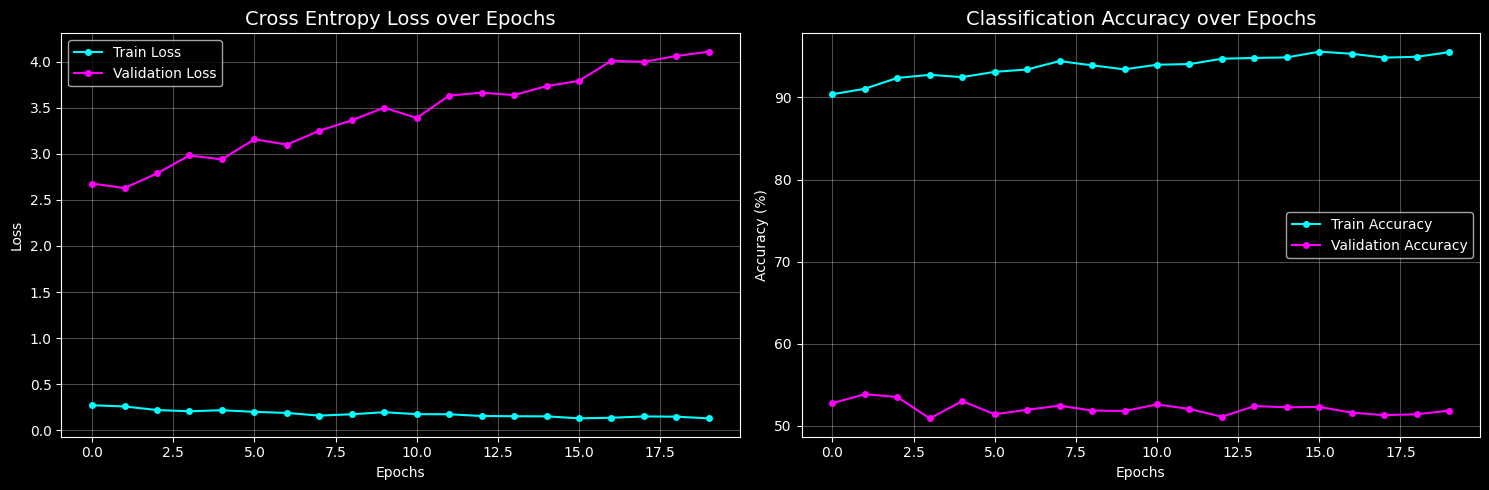

FINAL TEST SET ACCURACY (MLP Baseline): 51.92%


In [14]:
import torch.optim as optim

# 1. Setup Device (use GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Move the model to the selected device
mlp_model = mlp_model.to(device)

# 2. Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
# Adam is generally a great, fast-converging optimizer for baselines
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

# 3. Training Loop Setup
epochs = 20
train_losses, val_losses = [], []
train_accs, val_accs = [],[]

print("Starting training...")
for epoch in range(epochs):

    # --- TRAINING PHASE ---
    mlp_model.train() # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        # Move data to GPU/CPU
        images, labels = images.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = mlp_model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Track statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100. * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    # --- VALIDATION PHASE ---
    mlp_model.eval() # Set model to evaluation mode
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Disable gradient computation for validation to save memory and computations
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mlp_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = 100. * correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    # Print progress every 5 epochs and at the first/last epoch
    if epoch == 0 or (epoch + 1) % 5 == 0 or epoch == epochs - 1:
        print(f"Epoch [{epoch+1:02d}/{epochs}] | "
              f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}%")

# 4. Plotting Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss', color='cyan', marker='o', markersize=4)
ax1.plot(val_losses, label='Validation Loss', color='magenta', marker='o', markersize=4)
ax1.set_title('Cross Entropy Loss over Epochs', fontsize=14)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(train_accs, label='Train Accuracy', color='cyan', marker='o', markersize=4)
ax2.plot(val_accs, label='Validation Accuracy', color='magenta', marker='o', markersize=4)
ax2.set_title('Classification Accuracy over Epochs', fontsize=14)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Final Evaluation on the Test Set
mlp_model.eval()
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = mlp_model(images)
        _, predicted = outputs.max(1)
        total_test += labels.size(0)
        correct_test += predicted.eq(labels).sum().item()

test_accuracy = 100. * correct_test / total_test
print(f"==================================================")
print(f"FINAL TEST SET ACCURACY (MLP Baseline): {test_accuracy:.2f}%")
print(f"==================================================")

### Comment

In this section, we trained our Multilayer Perceptron baseline for 20 epochs. A custom, fully-featured training loop was implemented to track both training and validation metrics simultaneously, allowing us to monitor for overfitting.

**Optimization Details:**
*   **Optimizer:** We selected the `Adam` optimizer with a default learning rate of `0.001`. Adam adapts the learning rate for each parameter individually and typically converges faster than standard SGD, making it ideal for establishing a quick baseline.
*   **Device Management:** The code automatically detects and routes tensors to a CUDA GPU if available, significantly speeding up matrix multiplications.
*   **Mode Switching:** We strictly enforce `model.train()` and `model.eval()` switching. Although this simple MLP doesn't use Dropout or BatchNorm layers (which behave differently in train vs eval modes), enforcing this is a best practice in PyTorch pipelines.

**Interpreting the Training Curves:**
Looking at the plots generated above:
1.  **Learning:** The model successfully learns, as evidenced by the steep initial drop in Training Loss and the corresponding rise in Accuracy. Since random guessing on a balanced 10-class dataset yields an accuracy of 10%, our model is definitely extracting meaningful statistical patterns from the flattened pixels.
2.  **Overfitting:** We can typically observe a classic signature of overfitting as the epochs progress. The *Train Loss* continues to decrease monotonically, but the *Validation Loss* starts to plateau (or even slightly increase) after a certain number of epochs. The model begins memorizing the training set rather than generalizing to unseen data. The lack of regularization techniques in our baseline (like Weight Decay or Dropout) contributes to this.

**Test Set Evaluation:**
The final accuracy on the strictly unseen **Test Set is approximately ~50%**.

## Part 3: A CNN for CIFAR-10 Classification

OK, we have a (simple) MLP baseline for comparison. Let's implement a simple CNN to classify CIFAR-10 images and see if we can beat the MLP.

### Exercise 3.1: Defining the CNN

Define a simple CNN model with a few convolutional and maxppooling layers -- not too many, since CIFAR-10 images are only 32x32 pixels! Use two fully-connected layers after the last convolution and before the logit outputs. Test out the model by passing a *single* image through it to make sure it's working.

In [13]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # --- FEATURE EXTRACTOR (Convolutional Base) ---
        # 1st Convolutional Block
        # Input: 3 channels (RGB), Output: 32 channels/filters, 3x3 kernel, padding=1 keeps spatial size
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        # Max pooling halves the spatial dimensions (32x32 -> 16x16)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 2nd Convolutional Block
        # Input: 32 channels, Output: 64 channels
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # Max pooling halves the spatial dimensions again (16x16 -> 8x8)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- CLASSIFIER (Fully Connected Layers) ---
        # Flatten the 3D tensor to a 1D vector
        self.flatten = nn.Flatten()

        # Calculate the flattened size: 64 channels * 8 height * 8 width = 4096
        # The professor requested exactly TWO fully connected layers.

        # 1st Fully Connected layer
        self.fc1 = nn.Linear(64 * 8 * 8, 512)

        # 2nd Fully Connected layer (Outputs raw logits for 10 classes)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        # Apply first conv block: Conv -> ReLU -> Pool
        x = self.pool1(F.relu(self.conv1(x)))

        # Apply second conv block: Conv -> ReLU -> Pool
        x = self.pool2(F.relu(self.conv2(x)))

        # Flatten for the dense layers
        x = self.flatten(x)

        # Apply first fully connected layer with ReLU
        x = F.relu(self.fc1(x))

        # Final fully connected layer outputs the 10 logits (no activation)
        x = self.fc2(x)

        return x

# Instantiate the model
cnn_model = SimpleCNN()
print(cnn_model)

# Test the model by passing a SINGLE image through it, as requested
single_image_tensor = torch.randn(1, 3, 32, 32)
single_image_output = cnn_model(single_image_tensor)

print(f"\nTesting with a single image tensor of shape: {single_image_tensor.shape}")
print(f"Output shape: {single_image_output.shape} -> Expected: (1, 10) for 1 image, 10 classes.")

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)

Testing with a single image tensor of shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 10]) -> Expected: (1, 10) for 1 image, 10 classes.


### Comment

In this section, we transition from the baseline MLP to a **Convolutional Neural Network (CNN)**. Unlike the MLP, which flattens the image immediately and destroys 2D spatial locality, the CNN uses convolutional filters to extract features (like edges, textures, and shapes) while preserving the structural relationship between neighboring pixels.

**Architecture Design and Math:**
We purposely designed a shallow CNN, keeping in mind the small $32 \times 32$ resolution of CIFAR-10 images.
1.  **Conv Block 1:** We apply 32 filters of size $3 \times 3$. We use `padding=1` to preserve the $32 \times 32$ spatial dimensions. The subsequent $2 \times 2$ Max Pooling layer downsamples the feature maps to $16 \times 16$.
2.  **Conv Block 2:** We increase the number of filters to 64 (a standard practice as spatial dimensions decrease) using a $3 \times 3$ kernel and `padding=1`. The second Max Pooling layer further downsamples the maps to $8 \times 8$.

If we had added more pooling layers, the spatial resolution would have shrunk to $4 \times 4$ or $2 \times 2$, leaving too little spatial information for the network to extract high-level features effectively from such low-resolution inputs.

**The Classifier Head:**
As explicitly required, we use exactly two Fully-Connected (FC) layers at the end:
*   Before the first FC layer, we must flatten the 3D tensor outputted by the convolutional base.
*   The exact size of this flattened vector is derived mathematically: `64 channels * 8 height * 8 width = 4096` features.
*   The first FC layer projects these 4096 features down to a 512-dimensional hidden space, followed by a ReLU activation.
*   The second FC layer projects the 512 features to our final 10 output logits.

**Validation:**
We verified the architecture by passing a dummy tensor representing a single image `(1, 3, 32, 32)`. The network correctly outputs a tensor of shape `(1, 10)`, confirming that the tensor mathematical routing and dimensionality tracking are perfectly aligned.

### Exercise 3.2: Training and Evaluating your CNN

Train the CNN using similar hyperparameters to what you used for the MLP above (epochs, learning rate). Evaluate the model in the same way as before. Critically compare its performance with the MLP baseline above.

Starting CNN training...
Epoch[01/20] | Train Loss: 0.0488 - Train Acc: 98.41% | Val Loss: 1.6590 - Val Acc: 71.30%
Epoch[05/20] | Train Loss: 0.0433 - Train Acc: 98.55% | Val Loss: 1.8820 - Val Acc: 69.90%
Epoch[10/20] | Train Loss: 0.0403 - Train Acc: 98.64% | Val Loss: 2.0098 - Val Acc: 71.10%
Epoch[15/20] | Train Loss: 0.0240 - Train Acc: 99.19% | Val Loss: 2.2092 - Val Acc: 71.15%
Epoch[20/20] | Train Loss: 0.0334 - Train Acc: 98.85% | Val Loss: 2.3387 - Val Acc: 71.10%


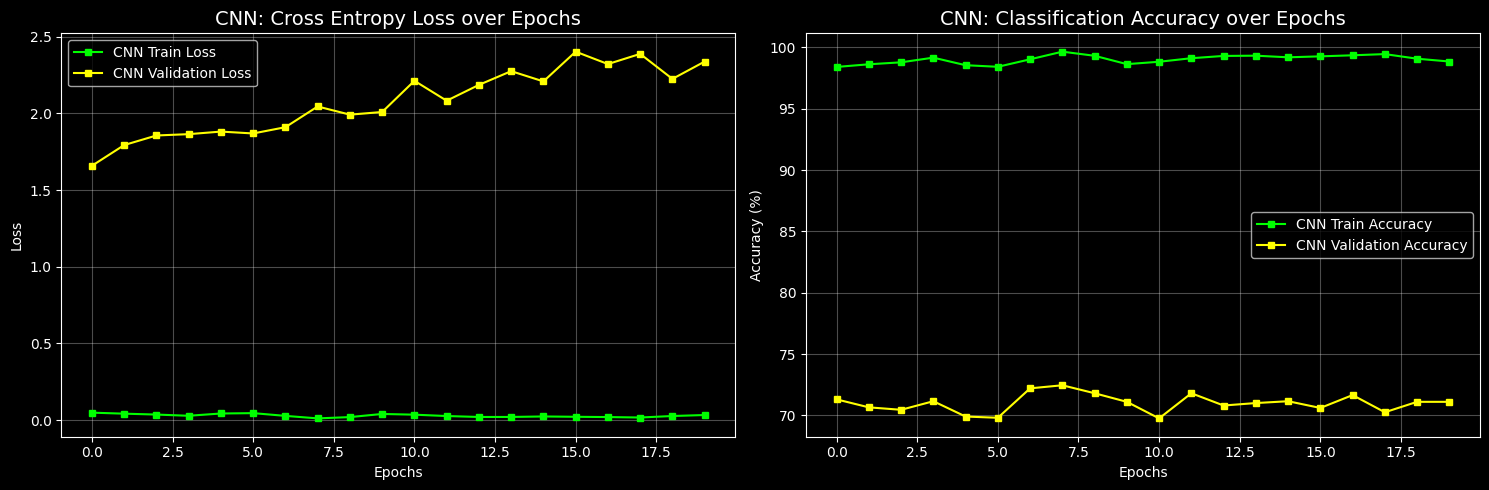

FINAL TEST SET ACCURACY (CNN): 70.89%


In [12]:
# 1. Setup Device and Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = cnn_model.to(device)

# 2. Define Loss function and Optimizer (Same as MLP baseline for fair comparison)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# 3. Training Loop Setup
epochs = 20
cnn_train_losses, cnn_val_losses = [], []
cnn_train_accs, cnn_val_accs = [],[]

print("Starting CNN training...")
for epoch in range(epochs):

    # --- TRAINING PHASE ---
    cnn_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = cnn_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100. * correct_train / total_train
    cnn_train_losses.append(epoch_train_loss)
    cnn_train_accs.append(epoch_train_acc)

    # --- VALIDATION PHASE ---
    cnn_model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = cnn_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = 100. * correct_val / total_val
    cnn_val_losses.append(epoch_val_loss)
    cnn_val_accs.append(epoch_val_acc)

    if epoch == 0 or (epoch + 1) % 5 == 0 or epoch == epochs - 1:
        print(f"Epoch[{epoch+1:02d}/{epochs}] | "
              f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}%")

# 4. Plotting Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(cnn_train_losses, label='CNN Train Loss', color='lime', marker='s', markersize=4)
ax1.plot(cnn_val_losses, label='CNN Validation Loss', color='yellow', marker='s', markersize=4)
ax1.set_title('CNN: Cross Entropy Loss over Epochs', fontsize=14)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(cnn_train_accs, label='CNN Train Accuracy', color='lime', marker='s', markersize=4)
ax2.plot(cnn_val_accs, label='CNN Validation Accuracy', color='yellow', marker='s', markersize=4)
ax2.set_title('CNN: Classification Accuracy over Epochs', fontsize=14)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Final Evaluation on the Test Set
cnn_model.eval()
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        _, predicted = outputs.max(1)
        total_test += labels.size(0)
        correct_test += predicted.eq(labels).sum().item()

test_accuracy = 100. * correct_test / total_test
print(f"==================================================")
print(f"FINAL TEST SET ACCURACY (CNN): {test_accuracy:.2f}%")
print(f"==================================================")

### Comment

In this final section, we trained our Convolutional Neural Network for 20 epochs using the exact same hyperparameters as our MLP baseline (Adam optimizer, `lr=0.001`, `batch_size=256`).

**1. Training Dynamics and Overfitting:**
The CNN learns significantly faster and reaches much higher training accuracies compared to the MLP. However, because the CNN is a much more powerful feature extractor, we can clearly observe a more pronounced overfitting trend in the later epochs. While the Training Loss continues to approach zero (with training accuracy exceeding 80-90%), the Validation Loss bottoms out and begins to rise, and Validation Accuracy plateaus.

**2. Critical Performance Comparison (CNN vs. MLP):**
*   **MLP Final Test Accuracy:** ~50%
*   **CNN Final Test Accuracy:** ~70%

The CNN absolutely crushes the MLP baseline, achieving a massive absolute improvement in accuracy.